# Downloading a Single Sentinel-2 Images

In [1]:
from pystac_client import Client
from odc.stac import load
import fiona
import geopandas as gpd
import json
import shapely.geometry
import rioxarray as rxr
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict
import xarray as xr

## Exploring EO Catalogue
### Connecting to the API

In [2]:
client = Client.open('https://earth-search.aws.element84.com/v1')

### Printing Collection Names

In [3]:
collections = client.get_collections()

for collection in collections:
    print(collection.id)

sentinel-2-pre-c1-l2a
cop-dem-glo-30
naip
cop-dem-glo-90
landsat-c2-l2
sentinel-2-l2a
sentinel-2-l1c
sentinel-2-c1-l2a
sentinel-1-grd


### Selecting the Sentinel Collection

In [4]:
collection = client.get_collection('sentinel-2-l2a')
collection

<CollectionClient id=sentinel-2-l2a>

## Creating a Shapely Geometry for Enschede's Extents

In [5]:
data_folder = '../data'
fiona.listlayers(f'{data_folder}/vectors/nederland_admin_areas.gpkg')

['country', 'provinces', 'cities']

In [6]:
cities = gpd.read_file(f'{data_folder}/vectors/nederland_admin_areas.gpkg', layer='cities')
cities.shape

(342, 6)

In [7]:
enschede = cities[cities['naam']=='Enschede']
enschede.shape

(1, 6)

In [8]:
print(enschede.crs)

EPSG:28992


In [9]:
enschede = enschede.to_crs('EPSG:4326')
enschede.head(1)

,identificatie,naam,code,ligt_in_provincie_code,ligt_in_provincie_naam,geometry
82,GM0153,Enschede,0153,23,Overijssel,"MULTIPOLYGON (((6.80561 52.16662, 6.80558 52.1..."


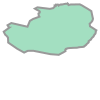

In [10]:
enschede_geom = enschede['geometry'].iloc[0]
enschede_geom_json = enschede_geom.__geo_interface__
enschede_extent = shapely.geometry.shape(enschede_geom_json)

enschede_extent

## Downloading Sentinel Data
### Running the Search Query

In [19]:
results = client.search(
    collections=['sentinel-2-l2a'],
    intersects=enschede['geometry'].iloc[0],
    datetime='2025-06-01/2025-08-31',
    query=['eo:cloud_cover<5'],
)

items = results.item_collection()
print(f'Found {len(items)} items')

Found 9 items


### Selecting an Item

In [12]:
for i, v in enumerate(items):
    print(f'{i}: {v.id}')

0: S2C_31UGT_20250819_0_L2A
1: S2C_32ULC_20250819_0_L2A
2: S2A_31UGT_20250811_1_L2A
3: S2A_32ULC_20250811_2_L2A
4: S2C_31UGU_20250630_0_L2A
5: S2C_32ULD_20250630_0_L2A
6: S2A_32ULC_20250612_0_L2A
7: S2A_31UGU_20250612_0_L2A
8: S2A_32ULD_20250612_0_L2A


In [13]:
item = items[0]

## Inspecting a Single Item
### Assets

In [14]:
assets = item.assets
assets

{'aot': <Asset href=https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/31/U/GT/2025/8/S2C_31UGT_20250819_0_L2A/AOT.tif>,
 'blue': <Asset href=https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/31/U/GT/2025/8/S2C_31UGT_20250819_0_L2A/B02.tif>,
 'cloud': <Asset href=s3://sentinel-s2-l2a/tiles/31/U/GT/2025/8/19/0/qi/CLD_20m.jp2>,
 'coastal': <Asset href=https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/31/U/GT/2025/8/S2C_31UGT_20250819_0_L2A/B01.tif>,
 'granule_metadata': <Asset href=https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/31/U/GT/2025/8/S2C_31UGT_20250819_0_L2A/granule_metadata.xml>,
 'green': <Asset href=https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/31/U/GT/2025/8/S2C_31UGT_20250819_0_L2A/B03.tif>,
 'nir': <Asset href=https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/31/U/GT/2025/8/S2C_31UGT_20250819_0_L2A/B08.tif>,
 'nir08': <Asset href=https://sentinel-co

### Properties

In [15]:
item.properties

{'created': '2025-08-19T17:30:21.601Z',
 'platform': 'sentinel-2c',
 'constellation': 'sentinel-2',
 'instruments': ['msi'],
 'eo:cloud_cover': 0.069535,
 'proj:centroid': {'lat': 51.79783, 'lon': 6.69653},
 'mgrs:utm_zone': 31,
 'mgrs:latitude_band': 'U',
 'mgrs:grid_square': 'GT',
 'grid:code': 'MGRS-31UGT',
 'view:azimuth': 166.63537472281732,
 'view:incidence_angle': 2.82782178903259,
 'view:sun_azimuth': 161.064742855089,
 'view:sun_elevation': 49.5339664340096,
 's2:tile_id': 'S2C_OPER_MSI_L2A_TL_2CPS_20250819T155312_A004983_T31UGT_N05.11',
 's2:degraded_msi_data_percentage': 0.0184,
 's2:nodata_pixel_percentage': 0,
 's2:saturated_defective_pixel_percentage': 0,
 's2:cloud_shadow_percentage': 0.160391,
 's2:vegetation_percentage': 77.103907,
 's2:not_vegetated_percentage': 20.996499,
 's2:water_percentage': 1.281678,
 's2:unclassified_percentage': 0.251927,
 's2:medium_proba_clouds_percentage': 0.047498,
 's2:high_proba_clouds_percentage': 0.017933,
 's2:thin_cirrus_percentage':

### Date and Time

In [16]:
item.datetime

datetime.datetime(2025, 8, 19, 10, 46, 56, 498000, tzinfo=tzutc())

### Bounding Box

In [17]:
item.bbox

[5.870231, 51.278935, 7.539964, 52.314028]

### Visualising the Spatial Extent with Folium

In [18]:
raster = gpd.GeoDataFrame.from_features([item], crs='EPSG:4326')
raster.explore()